In [1]:
import xarray as xr
import matplotlib.pyplot as plt 
import numpy as np

In [2]:
ds_jan = xr.open_dataset('/lustre/storeB/project/fou/hi/foccus/malene/ocean-ai/plot/yearly_means/January.nc')

In [3]:
ds_jan

<xarray.Dataset> Size: 2GB
Dimensions:           (time: 1, Y: 1148, X: 2747, s_rho: 40, s_w: 41)
Coordinates:
  * s_rho             (s_rho) float64 320B -0.9799 -0.9403 ... -0.004904
  * X                 (X) float64 22kB 0.0 800.0 1.6e+03 ... 2.196e+06 2.197e+06
  * Y                 (Y) float64 9kB 0.0 800.0 1.6e+03 ... 9.168e+05 9.176e+05
  * s_w               (s_w) float64 328B -1.0 -0.96 -0.9208 ... -0.01 0.0
    lon               (Y, X) float64 25MB ...
    lat               (Y, X) float64 25MB ...
  * time              (time) datetime64[ns] 8B 2024-01-31
Data variables:
    zeta              (time, Y, X) float32 13MB ...
    temperature       (time, s_rho, Y, X) float32 505MB ...
    salinity          (time, s_rho, Y, X) float32 505MB ...
    w                 (time, s_w, Y, X) float32 517MB ...
    ln_AKs            (time, s_w, Y, X) float32 517MB ...
    sea_mask          (time, Y, X) float32 13MB ...
    hc                (time) float64 8B ...
    Cs_r              (time, s_rho) float64 320B ...
    Cs_w              (time, s_w) float64 328B ...
    h                 (time, Y, X) float32 13MB ...
    projection_stere  (time) float64 8B ...
    depth             (time) float64 8B ...
Attributes: (12/31)
    id:                      f36dd872-f506-4ce2-a3ef-884f35a19db7
    naming_authority:        no.met
    operational_status:      scientific
    iso_topic_category:      oceans
    activity_type:           Numerical Simulation
    keywords_vocabulary:     GCMDSK:GCMD Science Keywords:https://gcmd.earthd...
    ...                      ...
    publisher_url:           https://www.met.no
    project:                 Norkyst_v3
    license:                 https://spdx.org/licenses/CC-BY-4.0 (CC-BY-4.0)
    title:                   Norkyst-800m - ROMS, Norkyst-800m ocean hindcast...
    summary:                 Norkyst-800m (Norwegian Coast 800m horizontal re...
    title_no:                Hindcast prognoser fra havmodellen Norkyst-800m,...

In [4]:
import glob 
files = glob.glob('/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/*.nc')
files = sorted(files)

In [17]:
def monthly_mean(month):
    files = glob.glob("/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/*.nc")
    files = sorted(files)
    #print(f'Glob identified the following files: {files}')

    list_m = []
    if month == 'January':
        dates = (0,31)
    elif month == 'February':
        dates = (31,60)
    elif month == 'March':
        dates = (60,91)
    elif month == 'April':
        dates = (91,121)
    elif month == 'May':
        dates = (121,152)
    elif month == 'June':
        dates = (152,182)
    elif month == 'July':
        dates = (182,213)
    elif month == 'August':
        dates = (213,244)
    elif month == 'September':
        dates = (244,274)
    elif month == 'October':
        dates = (274,305)
    elif month == 'November':
        dates = (305,335)
    elif month == 'December':
        dates = (335,366)
    else:
        raise ValueError('Please specify which month to calculate monthly means for, such as January')

    list_m.extend(files[dates[0]:dates[1]])
    print(list_m)
    #ds = xr.open_mfdataset(list_m, engine = 'h5netcdf', chunks={'time' : 1}).drop_vars(['u_eastward', 'v_northward', 'ubar_eastward', 'vbar_northward', 'Uwind_eastward', 'Vwind_northward']).resample(time = '1M').mean()
    #Because there is an issue with the encoding of the summaries and the keywords, we have to manually remove those 
    """
    if 'summary_no' in ds.attrs:
        del ds.attrs['summary_no']
    if 'keywords' in ds.attrs:
        del ds.attrs['keywords']
    """
monthly_mean(month= 'December')

['/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20241201.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20241202.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20241203.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20241204.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20241205.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20241206.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20241207.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20241208.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20241209.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlink

In [ ]:
def monthly_mean(month):
    files = glob.glob("/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/*.nc")
    files = sorted(files)
    print(f'Glob identified the following files: {files}')

    list = month
    list = []
    if month == 'January':
        dates = (0,31)
    elif month == 'February':
        dates = (31,60)
    elif month == 'March':
        dates = (60,91)
    elif month == 'April':
        dates = (91,121)
    elif month == 'May':
        dates = (121,152)
    elif month == 'June':
        dates = (152,182)
    elif month == 'July':
        dates = (182,213)
    elif month == 'August':
        dates = (213,244)
    elif month == 'September':
        dates = (244,274)
    elif month == 'October':
        dates = (274,305)
    elif month == 'November':
        dates = (305,335)
    elif month == 'December':
        dates = (335,366)
    else:
        raise ValueError('Please specify which month to calculate monthly means for, such as January')

    list.extend(files[dates[0]:dates[1]])
    ds = xr.open_mfdataset(list, engine = 'h5netcdf', chunks={'time' : 10}).drop_vars(['u_eastward', 'v_northward', 'ubar_eastward', 'vbar_northward', 'Uwind_eastward', 'Vwind_northward']).resample(time = '1M').mean()
    #Because there is an issue with the encoding of the summaries and the keywords, we have to manually remove those 
    if 'summary_no' in ds.attrs:
        del ds.attrs['summary_no']
    if 'keywords' in ds.attrs:
        del ds.attrs['keywords']

    ds.to_netcdf(f'{month}')

In [3]:
jan = []
feb = []
march = []
april = []
may = []
june = []
july = []
aug = []
sept = []
oct = []
nov = []
dec = []

months = (jan, feb, march, april, may, june, july, aug, sept, oct, nov, dec)
dates = (0, 31, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335)

for i in range(12):
    if i < 11:
        months[i].extend(files[dates[i]:dates[i+1]])
    elif i ==11:
        months[i].extend(files[dates[i]:])
    else:
        continue

In [4]:
#works
nov

['/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20241101.nc',
 '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20241102.nc',
 '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20241103.nc',
 '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20241104.nc',
 '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20241105.nc',
 '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20241106.nc',
 '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20241107.nc',
 '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20241108.nc',
 '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20241109.nc',
 '/lustre/storeB/project/fou/hi/foccus/dataset

In [5]:
ds = xr.open_mfdataset(nov, engine = 'h5netcdf').drop_vars(['u_eastward', 'v_northward', 'ubar_eastward', 'vbar_northward', 'Uwind_eastward', 'Vwind_northward']).resample(time = '1M').mean()

/lustre/storeB/project/fou/hi/foccus/.venv/lib64/python3.11/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


In [6]:
ds

<xarray.Dataset> Size: 2GB
Dimensions:           (time: 1, Y: 1148, X: 2747, s_rho: 40, s_w: 41)
Coordinates:
  * s_rho             (s_rho) float64 320B -0.9799 -0.9403 ... -0.004904
  * s_w               (s_w) float64 328B -1.0 -0.96 -0.9208 ... -0.01 0.0
  * X                 (X) float64 22kB 0.0 800.0 1.6e+03 ... 2.196e+06 2.197e+06
  * Y                 (Y) float64 9kB 0.0 800.0 1.6e+03 ... 9.168e+05 9.176e+05
    lon               (Y, X) float64 25MB dask.array<chunksize=(24, 2747), meta=np.ndarray>
    lat               (Y, X) float64 25MB dask.array<chunksize=(24, 2747), meta=np.ndarray>
  * time              (time) datetime64[ns] 8B 2024-11-30
Data variables:
    zeta              (time, Y, X) float32 13MB dask.array<chunksize=(1, 24, 2747), meta=np.ndarray>
    temperature       (time, s_rho, Y, X) float32 505MB dask.array<chunksize=(1, 1, 24, 2747), meta=np.ndarray>
    salinity          (time, s_rho, Y, X) float32 505MB dask.array<chunksize=(1, 1, 24, 2747), meta=np.ndarray>
    w                 (time, s_w, Y, X) float32 517MB dask.array<chunksize=(1, 1, 24, 2747), meta=np.ndarray>
    ln_AKs            (time, s_w, Y, X) float32 517MB dask.array<chunksize=(1, 1, 24, 2747), meta=np.ndarray>
    sea_mask          (time, Y, X) float32 13MB dask.array<chunksize=(1, 24, 2747), meta=np.ndarray>
    hc                (time) float64 8B 100.0
    Cs_r              (time, s_rho) float64 320B dask.array<chunksize=(1, 40), meta=np.ndarray>
    Cs_w              (time, s_w) float64 328B dask.array<chunksize=(1, 41), meta=np.ndarray>
    h                 (time, Y, X) float32 13MB dask.array<chunksize=(1, 24, 2747), meta=np.ndarray>
    projection_stere  (time) float64 8B -2.147e+09
    depth             (time) float64 8B -2.147e+09
Attributes: (12/33)
    id:                      ce028248-333c-4d1c-b929-f9e78b0e13b5
    naming_authority:        no.met
    operational_status:      scientific
    iso_topic_category:      oceans
    activity_type:           Numerical Simulation
    keywords_vocabulary:     GCMDSK:GCMD Science Keywords:https://gcmd.earthd...
    ...                      ...
    project:                 Norkyst_v3
    license:                 https://spdx.org/licenses/CC-BY-4.0 (CC-BY-4.0)
    title:                   Norkyst-800m - ROMS, Norkyst-800m ocean hindcast...
    summary:                 Norkyst-800m (Norwegian Coast 800m horizontal re...
    title_no:                Hindcast prognoser fra havmodellen Norkyst-800m,...
    summary_no:              NorKyst-800m (Norske kystområder med 800m horis...

In [9]:
ds_2 = xr.open_mfdataset(dec, engine = 'h5netcdf').drop_vars(['u_eastward', 'v_northward', 'ubar_eastward', 'vbar_northward', 'Uwind_eastward', 'Vwind_northward']).resample(time = '1M').mean()

/lustre/storeB/project/fou/hi/foccus/.venv/lib64/python3.11/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


In [10]:
ds_2

<xarray.Dataset> Size: 2GB
Dimensions:           (time: 1, Y: 1148, X: 2747, s_rho: 40, s_w: 41)
Coordinates:
  * s_rho             (s_rho) float64 320B -0.9799 -0.9403 ... -0.004904
  * s_w               (s_w) float64 328B -1.0 -0.96 -0.9208 ... -0.01 0.0
  * X                 (X) float64 22kB 0.0 800.0 1.6e+03 ... 2.196e+06 2.197e+06
  * Y                 (Y) float64 9kB 0.0 800.0 1.6e+03 ... 9.168e+05 9.176e+05
    lon               (Y, X) float64 25MB dask.array<chunksize=(24, 2747), meta=np.ndarray>
    lat               (Y, X) float64 25MB dask.array<chunksize=(24, 2747), meta=np.ndarray>
  * time              (time) datetime64[ns] 8B 2024-12-31
Data variables:
    zeta              (time, Y, X) float32 13MB dask.array<chunksize=(1, 24, 2747), meta=np.ndarray>
    temperature       (time, s_rho, Y, X) float32 505MB dask.array<chunksize=(1, 1, 24, 2747), meta=np.ndarray>
    salinity          (time, s_rho, Y, X) float32 505MB dask.array<chunksize=(1, 1, 24, 2747), meta=np.ndarray>
    w                 (time, s_w, Y, X) float32 517MB dask.array<chunksize=(1, 1, 24, 2747), meta=np.ndarray>
    ln_AKs            (time, s_w, Y, X) float32 517MB dask.array<chunksize=(1, 1, 24, 2747), meta=np.ndarray>
    sea_mask          (time, Y, X) float32 13MB dask.array<chunksize=(1, 24, 2747), meta=np.ndarray>
    hc                (time) float64 8B 100.0
    Cs_r              (time, s_rho) float64 320B dask.array<chunksize=(1, 40), meta=np.ndarray>
    Cs_w              (time, s_w) float64 328B dask.array<chunksize=(1, 41), meta=np.ndarray>
    h                 (time, Y, X) float32 13MB dask.array<chunksize=(1, 24, 2747), meta=np.ndarray>
    projection_stere  (time) float64 8B -2.147e+09
    depth             (time) float64 8B -2.147e+09
Attributes: (12/33)
    id:                      fa808f56-4f51-402b-bff7-2f57ad047c3d
    naming_authority:        no.met
    operational_status:      scientific
    iso_topic_category:      oceans
    activity_type:           Numerical Simulation
    keywords_vocabulary:     GCMDSK:GCMD Science Keywords:https://gcmd.earthd...
    ...                      ...
    project:                 Norkyst_v3
    license:                 https://spdx.org/licenses/CC-BY-4.0 (CC-BY-4.0)
    title:                   Norkyst-800m - ROMS, Norkyst-800m ocean hindcast...
    summary:                 Norkyst-800m (Norwegian Coast 800m horizontal re...
    title_no:                Hindcast prognoser fra havmodellen Norkyst-800m,...
    summary_no:              NorKyst-800m (Norske kystområder med 800m horis...

In [11]:
ds_tot = xr.concat([ds, ds_2], dim = 'time')
ds_tot

<xarray.Dataset> Size: 4GB
Dimensions:           (time: 2, Y: 1148, X: 2747, s_rho: 40, s_w: 41)
Coordinates:
  * s_rho             (s_rho) float64 320B -0.9799 -0.9403 ... -0.004904
  * s_w               (s_w) float64 328B -1.0 -0.96 -0.9208 ... -0.01 0.0
  * X                 (X) float64 22kB 0.0 800.0 1.6e+03 ... 2.196e+06 2.197e+06
  * Y                 (Y) float64 9kB 0.0 800.0 1.6e+03 ... 9.168e+05 9.176e+05
    lon               (Y, X) float64 25MB 8.7 8.706 8.711 ... 18.29 18.31 18.33
    lat               (Y, X) float64 25MB 54.29 54.3 54.31 ... 75.71 75.72 75.73
  * time              (time) datetime64[ns] 16B 2024-11-30 2024-12-31
Data variables:
    zeta              (time, Y, X) float32 25MB dask.array<chunksize=(1, 24, 2747), meta=np.ndarray>
    temperature       (time, s_rho, Y, X) float32 1GB dask.array<chunksize=(1, 1, 24, 2747), meta=np.ndarray>
    salinity          (time, s_rho, Y, X) float32 1GB dask.array<chunksize=(1, 1, 24, 2747), meta=np.ndarray>
    w                 (time, s_w, Y, X) float32 1GB dask.array<chunksize=(1, 1, 24, 2747), meta=np.ndarray>
    ln_AKs            (time, s_w, Y, X) float32 1GB dask.array<chunksize=(1, 1, 24, 2747), meta=np.ndarray>
    sea_mask          (time, Y, X) float32 25MB dask.array<chunksize=(1, 24, 2747), meta=np.ndarray>
    hc                (time) float64 16B 100.0 100.0
    Cs_r              (time, s_rho) float64 640B dask.array<chunksize=(1, 40), meta=np.ndarray>
    Cs_w              (time, s_w) float64 656B dask.array<chunksize=(1, 41), meta=np.ndarray>
    h                 (time, Y, X) float32 25MB dask.array<chunksize=(1, 24, 2747), meta=np.ndarray>
    projection_stere  (time) float64 16B -2.147e+09 -2.147e+09
    depth             (time) float64 16B -2.147e+09 -2.147e+09
Attributes: (12/33)
    id:                      ce028248-333c-4d1c-b929-f9e78b0e13b5
    naming_authority:        no.met
    operational_status:      scientific
    iso_topic_category:      oceans
    activity_type:           Numerical Simulation
    keywords_vocabulary:     GCMDSK:GCMD Science Keywords:https://gcmd.earthd...
    ...                      ...
    project:                 Norkyst_v3
    license:                 https://spdx.org/licenses/CC-BY-4.0 (CC-BY-4.0)
    title:                   Norkyst-800m - ROMS, Norkyst-800m ocean hindcast...
    summary:                 Norkyst-800m (Norwegian Coast 800m horizontal re...
    title_no:                Hindcast prognoser fra havmodellen Norkyst-800m,...
    summary_no:              NorKyst-800m (Norske kystområder med 800m horis...

In [12]:
def it_wont_work(ds):
    bad = []
    def check(where, s):
        if isinstance(s,str):
            try:
                s.encode('utf-8')
            except UnicodeEncodeError as e:
                bad.append((where, s, str(e)))

    for k,v in ds.attrs.items():
        check(f'ds.attrs[{k!r}]',v)

    for name, da in ds.data_vars.items():
        for k,v in ds.attrs.items():
            check(f'{name}.attrs[{k!r}]',v)
    
    for name, coord in ds.coords.items():
        for k,v in coord.attrs.items():
            check(f'{name}.attrs[{k!r}]',v)

    return bad

bad = it_wont_work(ds_tot)


In [14]:
bad

[("ds.attrs['keywords']",
  'GCMDSK:EARTH SCIENCE SERVICES > MODELS > OCEAN GENERAL CIRCULATIONMODELS (OGCM)/REGIONAL OCEAN MODELS, GCMDSK:Earth Science > Oceans > Ocean Temperature  > WATER TEMPERATURE, GCMDSK:Earth Science > Oceans > Salinity/Density > SALINITY, GCMDSK:Earth Science > Oceans > Ocean Circulation > OCEAN CURRENTS, GCMDSK:Earth Science > Oceans > Sea Ice > SEA ICE CONCENTRATION, GEMET:Oceanographic geographical features, NORTHEMES:V\udcc3\udca6r og klima, NORTHEMES:Kyst og fiskeri',
  "'utf-8' codec can't encode characters in position 423-424: surrogates not allowed"),
 ("ds.attrs['summary_no']",
  'NorKyst-800m (Norske kystomr\udcc3\udca5der med 800m horisontal oppl\udcc3\udcb8sning) er et numerisk h\udcc3\udcb8yoppl\udcc3\udcb8slig, havmodellerings-system basert p\udcc3\udca5 ROMS modellen. Den har potensialet til \udcc3\udca5 produsere milj\udcc3\udcb8-relatert informasjon som dekker alle kystomr\udcc3\udca5der i Norge for bruk som driverdata i applikasjoner for over

In [15]:
#Okay the problem lies in attributes summaries and keywords, we can just remove those because they dont contain values
if 'summary_no' in ds_tot.attrs:
    del ds_tot.attrs['summary_no']
if 'keywords' in ds_tot.attrs:
    del ds_tot.attrs['keywords']

In [20]:
def monthly_mean(month):
    files = glob.glob("/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/*.nc")
    files = sorted(files)
    #print(f'Glob identified the following files: {files}')

    list_m = []
    if month == 'January':
        dates = (0,31)
    elif month == 'February':
        dates = (31,60)
    elif month == 'March':
        dates = (60,91)
    elif month == 'April':
        dates = (91,121)
    elif month == 'May':
        dates = (121,152)
    elif month == 'June':
        dates = (152,182)
    elif month == 'July':
        dates = (182,213)
    elif month == 'August':
        dates = (213,244)
    elif month == 'September':
        dates = (244,274)
    elif month == 'October':
        dates = (274,305)
    elif month == 'November':
        dates = (305,335)
    elif month == 'December':
        dates = (335,366)
    else:
        raise ValueError('Please specify which month to calculate monthly means for, such as January')

    list_m.extend(files[dates[0]:dates[1]])
    print(f'The files identified for the selected month are: {list_m}')
    ds = xr.open_mfdataset(list_m, engine = 'h5netcdf', chunks={'time' : 10}).drop_vars(['u_eastward', 'v_northward', 'ubar_eastward', 'vbar_northward', 'Uwind_eastward', 'Vwind_northward']).resample(time = '1M').mean()
    #Because there is an issue with the encoding of the summaries and the keywords, we have to manually remove those 
    if 'summary_no' in ds.attrs:
        del ds.attrs['summary_no']
    if 'keywords' in ds.attrs:
        del ds.attrs['keywords']

months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
for m in months:
    monthly_mean(m)

The files identified for the selected month are: ['/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240101.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240102.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240103.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240104.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240105.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240106.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240107.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240108.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240109.nc', '/lus

In [21]:
def monthmean_sesavg():
    files = glob.glob("/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/*.nc")
    files = sorted(files)

    list_jan = []
    list_jan.extend(files[0:31])
    print(f'The identified filepaths for January are: {list_jan}')
    list_feb = []
    list_feb.extend(files[31:60])
    print(f'The identified filepaths for February are: {list_feb}')
    list_march = []
    list_march.extend(files[60:91])
    print(f'The identified filepaths for March are: {list_march}')
    list_apr = []
    list_apr.extend(files[91:121])
    print(f'The identified filepaths for April are: {list_apr}')
    list_may = []
    list_may.extend(files[121:152])
    print(f'The identified filepaths for May are: {list_may}')
    list_june = []
    list_june.extend(files[152:182])
    print(f'The identified filepaths for June are: {list_june}')
    list_july = []
    list_july.extend(files[182:213])
    print(f'The identified filepaths for July are: {list_july}')
    list_aug = []
    list_aug.extend(files[213:244])
    print(f'The identified filepaths for August are: {list_aug}')
    list_sept = []
    list_sept.extend(files[244:274])
    print(f'The identified filepaths for September are: {list_sept}')
    list_oct = []
    list_oct.extend(files[274:305])
    print(f'The identified filepaths for October are: {list_oct}')
    list_nov = []
    list_nov.extend(files[305:335])
    print(f'The identified filepaths for November are: {list_nov}')
    list_dec = []
    list_dec.extend(files[335:366])
    print(f'The identified filepaths for December are: {list_dec}')
    

In [24]:
monthmean_sesavg()

The identified filepaths for January are: ['/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240101.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240102.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240103.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240104.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240105.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240106.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240107.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240108.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240109.nc', '/lustre/sto

In [29]:
import time
fp = '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/*.nc'

In [ ]:
#remake into an easier function

def mean_sesavg(save_path):

    start_time = time.perf_counter()

    files = glob.glob(fp)
    files = sorted(files)

    def month_mean(nc_files, start_date, end_date, month_name):
        list_month = []
        list_month.extend(nc_files[start_date:end_date])
        print(f'The identified filepaths for {month_name} are: {list_month}')
        ds = xr.open_mfdataset(list_month, engine = 'h5netcdf', chunks={'time' : 10}).drop_vars(['u_eastward', 'v_northward', 'ubar_eastward', 'vbar_northward', 'Uwind_eastward', 'Vwind_northward']).resample(time = '1M').mean()
        print(f'The month of {month_name} has the following files: {list_month}')
        return ds

    ds_jan = month_mean(files, 0, 31, 'January')
    ds_feb = month_mean(files, 31, 60, 'February')
    ds_march = month_mean(files, 60, 91, 'March')
    ds_april = month_mean(files, 91, 121, 'April')
    ds_may = month_mean(files, 121, 152, 'May')
    ds_june = month_mean(files, 152, 182, 'June')
    ds_july = month_mean(files, 182, 213, 'July')
    ds_aug = month_mean(files, 213, 244, 'August')
    ds_sept = month_mean(files, 244, 274, 'September')
    ds_oct = month_mean(files, 274, 305, 'October')
    ds_nov = month_mean(files, 305, 335, 'November')
    ds_dec = month_mean(files, 335, 366, 'December')

    ds = xr.concat([ds_jan, ds_feb, ds_march, ds_april, ds_may, ds_june, ds_july, ds_aug, ds_sept, ds_oct, ds_nov, ds_dec], dim = 'time')
    if 'summary_no' in ds.attrs:
        del ds.attrs['summary_no']
    if 'keywords' in ds.attrs:
        del ds.attrs['keywords']

    #This code is from the xarray tutorial: https://docs.xarray.dev/en/latest/examples/monthly-means.html
    month_length = ds.time.dt.days_in_month
    weights = (month_length.groupby("time.season") / month_length.groupby("time.season").sum())
    # Test that the sum of the weights for each season is 1.0
    np.testing.assert_allclose(weights.groupby("time.season").sum().values, np.ones(4))
    # Calculate the weighted average
    ds_weighted = (ds * weights).groupby("time.season").sum(dim="time")

    ds_weighted.to_netcdf(f'{save_path}', engine = 'netcdf4')
    print(f'The datasets of the seasonal averages have been transformed into netdf files')

    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    statement_time = f'End of function. Elapsed time is: {elapsed_time}'
    return statement_time

if __name__ == '__main__':
    parser = argparse.ArgumentParser(description = 'Calculation of seasonal averages of Norkyst dataset with monthly means')
    parser.add_argument('-sp' , '--save_path', help = 'Please enter wished saving path for the new netcdf file')
    args = parser.parse_args()
    save_path = args.save_path

mean_sesavg(save_path)

In [33]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
import cartopy 
import cmocean 
import cartopy.crs as ccrs 
import cartopy.feature as cfeature

In [36]:
foccus = '/lustre/storeB/project/fou/hi/foccus'
filepath = 'malene/run-anemoi-ocean/ppi/external_checkpoint_inference/Inference_res/2024-04-02_.ckpt_e010_s020000.nc' #inference results from my own run
#open with Mateusz method
from dataloader import open_dataset
ds_lof = open_dataset(file = f'{foccus}/{filepath}', region= 'lofoten').dataset
ds_sula = open_dataset(file = f'{foccus}/{filepath}', region= 'sulafjorden').dataset
ds_oslo = open_dataset(file = f'{foccus}/{filepath}', region= 'oslofjorden').dataset

In [92]:
def mean(ds):
    mean_u_vel = ds['u_eastward_0'].resample(time = 'D').mean(dim = 'time')
    mean_v_vel = ds['v_northward_0'].resample(time = 'D').mean(dim = 'time')
    return mean_u_vel, mean_v_vel

In [93]:
lofoten_u, lofoten_v = mean(ds_lof)
sula_u, sula_v = mean(ds_sula)
oslo_u, oslo_v = mean(ds_oslo)

In [41]:
ds = xr.open_dataset(f'{foccus}/{filepath}')

#Also select an area out in the ocean
import pyresample
#select an area
lon_min, lon_max = 11.83083, 15.59072
lat_min, lat_max = 67.41791, 69.20699


lon_ulc, lon_llc = 16.5, 16.5
lon_lrc, lon_urc = 23.4, 24.1
lat_urc, lat_ulc = 74.4, 74.4
lat_llc, lat_lrc = 73.1, 73.1

#lon_re = ds_norkyst.lon.astype(np.float64)
#lat_re = ds_norkyst.lat.astype(np.float64)

ds_grid_n = pyresample.geometry.GridDefinition(lons=ds.longitude.values, lats = ds.latitude.values)
pos_geo_n = pyresample.geometry.SwathDefinition(lons=[lon_llc, lon_lrc, lon_urc, lon_ulc], lats=[lat_llc, lat_lrc, lat_urc, lat_ulc])

_, valid_output_index, index_array, distance_array = pyresample.kd_tree.get_neighbour_info(
                                                    source_geo_def = ds_grid_n,
                                                    target_geo_def = pos_geo_n,
                                                    radius_of_influence = 800,
                                                    neighbours = 1)

index_array_2d = np.unravel_index(index_array, ds_grid_n.shape)

(x_indices,y_indices) =  np.array([index_array_2d[0][0], index_array_2d[0][1], index_array_2d[0][2], index_array_2d[0][3]]), np.array([index_array_2d[1][0], index_array_2d[1][1], index_array_2d[1][2], index_array_2d[1][3]])
x_min, x_max = x_indices.min(), x_indices.max()
y_min, y_max = y_indices.min(), y_indices.max()

#make sure its correct
print(f'X min: {x_min}, X max: {x_max}')
print(f'Y min: {y_min}, Y max: {y_max}')

ds_ocean = ds.isel(Y=slice(y_min, y_max+1), X = slice(x_min, x_max +1))

X min: 783, X max: 1090
Y min: 2430, Y max: 2744


In [94]:
ocean_u, ocean_v = mean(ds_ocean)

In [106]:
lofoten_u

<xarray.DataArray 'u_eastward_0' (time: 3, X: 747, Y: 805)> Size: 7MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(3, 747, 805), dtype=float32)
Coordinates:
  * X        (X) float64 6kB 2.488e+05 2.496e+05 ... 8.448e+05 8.456e+05
  * Y        (Y) float64 6kB 1.173e+06 1.174e+06 ... 1.815e+06 1.816e+06
  * time     (time) datetime64[ns] 24B 2024-04-02 2024-04-03 2024-04-04

In [95]:
def calc_fh(ds):
    h = ds.h 
    f = ds.f
    f_h = f.values / h.values
    #check that it works
    print(f'f_h has dimensions: {f_h.shape}')
    return f_h 

In [96]:
fh_lof = calc_fh(ds_lof)
fh_sula = calc_fh(ds_sula)
fh_oslo = calc_fh(ds_oslo)
fh_ocean = calc_fh(ds_ocean)

f_h has dimensions: (17, 747, 805)
f_h has dimensions: (17, 289, 235)
f_h has dimensions: (17, 229, 253)
f_h has dimensions: (17, 308, 315)


In [97]:
#Ensure legitimite vals 
result_osl = fh_oslo[~np.isnan(fh_oslo)]
result_sula = fh_sula[~np.isnan(fh_sula)]
result_lof = fh_lof[~np.isnan(fh_lof)]

In [98]:
#perfect 
result_sula
result_lof
result_osl

array([1.2435579e-05, 1.2435266e-05, 1.2436074e-05, ..., 1.2628452e-05,
       1.2629248e-05, 1.2630042e-05], shape=(30007,), dtype=float32)

In [99]:
#custom steps
step = 5
min_l = -0.5e-5 
max_l = 1.44e-5
custom = np.linspace(min_l, max_l, 20)

In [112]:
def fh(area, fh, u_vel, v_vel, title, step = 5, min_l = -0.5e-5, max_l = 1.44e-5):
    fig, ax = plt.subplots(figsize = (10,12), subplot_kw={'projection' : ccrs.NorthPolarStereo()})
    step = step
    min_l = min_l
    max_l = max_l
    custom = np.linspace(min_l, max_l, 20)
    im = ax.contour(area.longitude.values, area.latitude.values, fh[0,:,:], levels = custom, transform = ccrs.PlateCarree(), zorder = 2, color = 'black')
    im_fill = ax.contourf(area.longitude.values, area.latitude.values, fh[0,:,:], levels = custom, transform = ccrs.PlateCarree(), zorder = 1, cmap = cmocean.cm.topo)
    ax.quiver(area.longitude.values[::step, ::step], area.latitude.values[::step, ::step], u_vel[0,:,:].values[::step, ::step], v_vel[0,:,:].values[::step, ::step], transform = ccrs.PlateCarree(), color = 'black', alpha = 0.6, scale = 20)
    cax = fig.add_axes([ax.get_position().x1+0.025, ax.get_position().y0, 0.025, ax.get_position().height])
    cbar = fig.colorbar(im_fill, ax=ax, cax = cax, extend = 'both')
    cbar.ax.set_title(r'$\frac{f}{h}$')
    gl = ax.gridlines(crs = ccrs.PlateCarree(), draw_labels = True, linewidth = 1, color = 'black', alpha = 0.1, linestyle = '--')
    gl.xlabels_top = False 
    gl.ylabels_right = False 
    ax.set_title(f'{title}')
    ax.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = 'black')
    plt.show()

/lustre/storeB/project/fou/hi/foccus/.venv/lib64/python3.11/site-packages/cartopy/mpl/geoaxes.py:1600: UserWarning: The following kwargs were not used by contour: 'color'
  result = super().contour(*args, **kwargs)


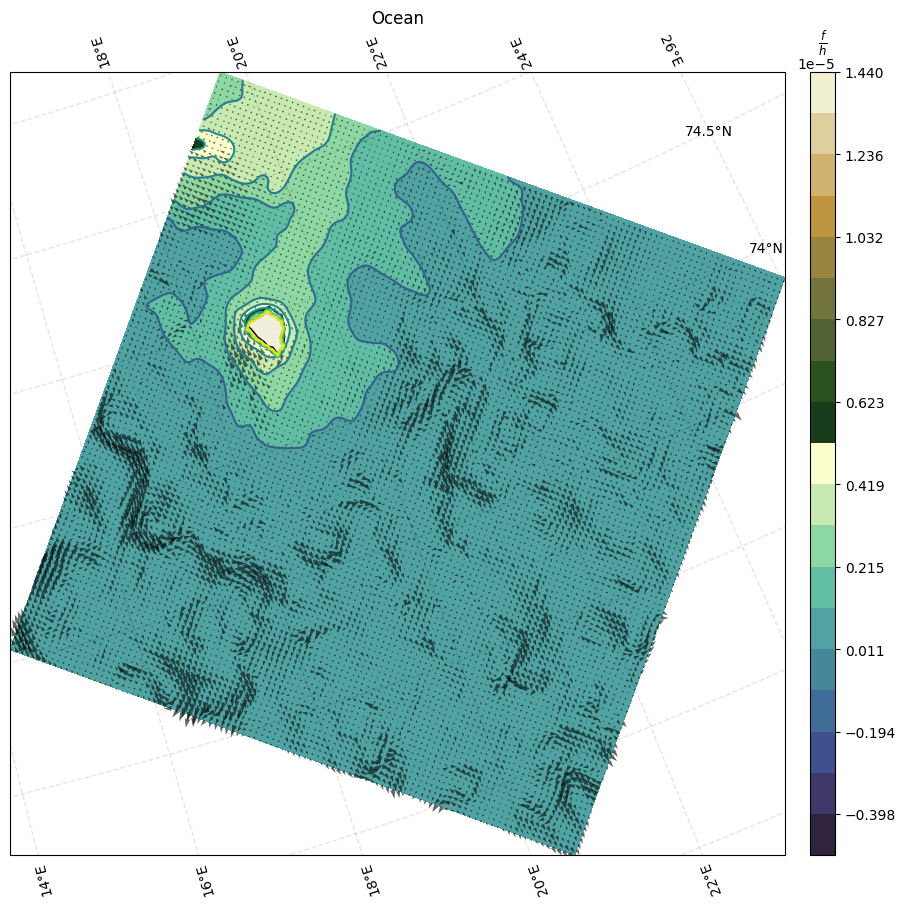

In [113]:
fh(area=ds_ocean, fh = fh_ocean, u_vel=ocean_u, v_vel=ocean_v, title='Ocean', step = 3)

/lustre/storeB/project/fou/hi/foccus/.venv/lib64/python3.11/site-packages/cartopy/mpl/geoaxes.py:1600: UserWarning: The following kwargs were not used by contour: 'color'
  result = super().contour(*args, **kwargs)


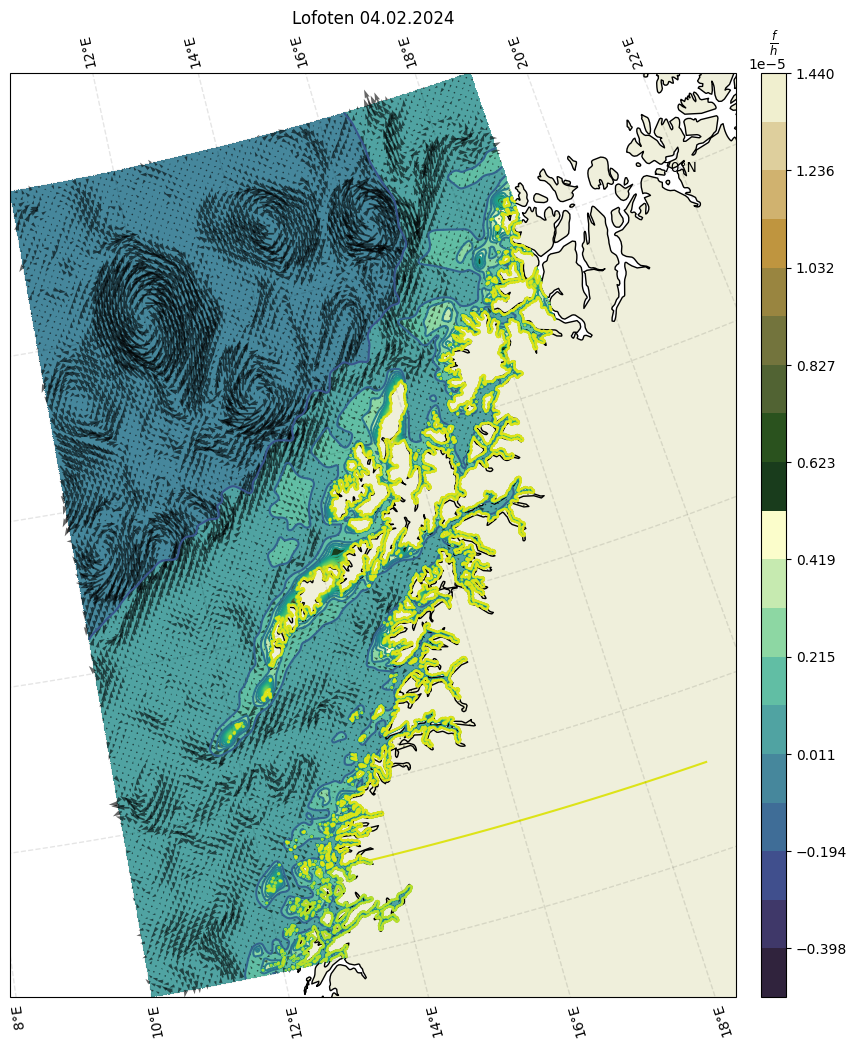

In [116]:
fh(area=ds_lof, fh = fh_lof, u_vel=lofoten_u, v_vel=lofoten_v, title='Lofoten 04.02.2024')

In [146]:
norkyst_p = '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240402.nc'
ds_norkystt = xr.open_dataset(norkyst_p)


In [155]:
import pyresample
#select an area
lon_min, lon_max = 11.83083, 15.59072
lat_min, lat_max = 67.41791, 69.20699


lon_ulc, lon_llc = 11.83, 11.83
lon_lrc, lon_urc = 15.59, 15.59
lat_urc, lat_ulc = 69.21, 69.21
lat_llc, lat_lrc = 67.41, 67.41

#lon_re = ds_norkyst.lon.astype(np.float64)
#lat_re = ds_norkyst.lat.astype(np.float64)

ds_grid = pyresample.geometry.GridDefinition(lons=ds.longitude.values, lats = ds.latitude.values)
pos_geo = pyresample.geometry.SwathDefinition(lons=[lon_llc, lon_lrc, lon_urc, lon_ulc], lats=[lat_llc, lat_lrc, lat_urc, lat_ulc])

_, valid_output_index, index_array, distance_array = pyresample.kd_tree.get_neighbour_info(
                                                    source_geo_def = ds_grid,
                                                    target_geo_def = pos_geo,
                                                    radius_of_influence = 800,
                                                    neighbours = 1)

index_array_2d = np.unravel_index(index_array, ds_grid.shape)

(x_indices,y_indices) =  np.array([index_array_2d[0][0], index_array_2d[0][1], index_array_2d[0][2], index_array_2d[0][3]]), np.array([index_array_2d[1][0], index_array_2d[1][1], index_array_2d[1][2], index_array_2d[1][3]])
x_min, x_max = x_indices.min(), x_indices.max()
y_min, y_max = y_indices.min(), y_indices.max()

#make sure its correct
print(f'X min: {x_min}, X max: {x_max}')
print(f'Y min: {y_min}, Y max: {y_max}')

ds_norkyst = ds_norkystt.isel(Y=slice(y_min, y_max+1), X = slice(x_min, x_max +1))

X min: 572, X max: 862
Y min: 1680, Y max: 1986


In [153]:
ds_norkyst

<xarray.Dataset> Size: 2kB
Dimensions:           (time: 24, Y: 0, X: 1, s_rho: 40, s_w: 41)
Coordinates:
  * time              (time) datetime64[ns] 192B 2024-04-02 ... 2024-04-02T23...
  * s_rho             (s_rho) float64 320B -0.9799 -0.9403 ... -0.004904
  * X                 (X) float64 8B 800.0
  * Y                 (Y) float64 0B 
  * s_w               (s_w) float64 328B -1.0 -0.96 -0.9208 ... -0.01 0.0
    lon               (Y, X) float64 0B ...
    lat               (Y, X) float64 0B ...
Data variables: (12/18)
    Uwind_eastward    (time, Y, X) float32 0B ...
    Vwind_northward   (time, Y, X) float32 0B ...
    zeta              (time, Y, X) float32 0B ...
    ubar_eastward     (time, Y, X) float32 0B ...
    vbar_northward    (time, Y, X) float32 0B ...
    u_eastward        (time, s_rho, Y, X) float32 0B ...
    ...                ...
    hc                float64 8B ...
    Cs_r              (s_rho) float64 320B ...
    Cs_w              (s_w) float64 328B ...
    h                 (Y, X) float32 0B ...
    projection_stere  int32 4B ...
    depth             int32 4B ...
Attributes: (12/33)
    id:                      572391bb-878e-4153-bac1-2bd854d73fe4
    naming_authority:        no.met
    operational_status:      scientific
    iso_topic_category:      oceans
    activity_type:           Numerical Simulation
    keywords_vocabulary:     GCMDSK:GCMD Science Keywords:https://gcmd.earthd...
    ...                      ...
    project:                 Norkyst_v3
    license:                 https://spdx.org/licenses/CC-BY-4.0 (CC-BY-4.0)
    title:                   Norkyst-800m - ROMS, Norkyst-800m ocean hindcast...
    summary:                 Norkyst-800m (Norwegian Coast 800m horizontal re...
    title_no:                Hindcast prognoser fra havmodellen Norkyst-800m,...
    summary_no:              NorKyst-800m (Norske kystområder med 800m horiso...

In [148]:
def mean_nor(ds):
    mean_u_vel = ds['u_eastward'].resample(time = 'D').mean(dim = 'time')
    mean_v_vel = ds['v_northward'].resample(time = 'D').mean(dim = 'time')
    return mean_u_vel, mean_v_vel

In [149]:
u_nor, v_nor = mean_nor(ds_norkyst)
h_nor = ds_norkyst.h
omega = 7.2921e-5
lat_nor = ds_norkyst.lat
lat_nor_rad = np.deg2rad(lat_nor)
f_nor = 2 * omega * np.sin(lat_nor_rad)
fh_nor_vals = f_nor/h_nor

In [150]:
fh_nor_vals.dims

('Y', 'X')

In [130]:
def fh_nor(area, fh, u_vel, v_vel, title, step = 5, min_l = -0.5e-5, max_l = 1.44e-5):
    fig, ax = plt.subplots(figsize = (10,12), subplot_kw={'projection' : ccrs.NorthPolarStereo()})
    step = step
    min_l = min_l
    max_l = max_l
    custom = np.linspace(min_l, max_l, 20)
    im = ax.contour(area.lon.values, area.lat.values, fh[:,:], levels = custom, transform = ccrs.PlateCarree(), zorder = 2, color = 'black')
    im_fill = ax.contourf(area.lon.values, area.lat.values, fh[:,:], levels = custom, transform = ccrs.PlateCarree(), zorder = 1, cmap = cmocean.cm.topo)
    ax.quiver(area.lon.values[::step, ::step], area.lat.values[::step, ::step], u_vel[0,:,:].values[::step, ::step], v_vel[0,:,:].values[::step, ::step], transform = ccrs.PlateCarree(), color = 'black', alpha = 0.6, scale = 20)
    cax = fig.add_axes([ax.get_position().x1+0.025, ax.get_position().y0, 0.025, ax.get_position().height])
    cbar = fig.colorbar(im_fill, ax=ax, cax = cax, extend = 'both')
    cbar.ax.set_title(r'$\frac{f}{h}$')
    gl = ax.gridlines(crs = ccrs.PlateCarree(), draw_labels = True, linewidth = 1, color = 'black', alpha = 0.1, linestyle = '--')
    gl.xlabels_top = False 
    gl.ylabels_right = False 
    ax.set_title(f'{title}')
    ax.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = 'black')
    plt.show()

In [156]:
#fh_nor(ds_norkyst, fh_nor_vals, u_nor, v_nor, 'Norkyst 04.02.2024')